# Patching geometries gallery

`SpatialPatcher` ships five `Geometry` types, each dispatching on the
`Domain` it gets handed. This notebook walks through the four canonical
(Geometry × Domain) pairings on synthetic data:

1. `SpatialRectangular` × `RasterDomain` — tiling a raster.
2. `SpatialSphericalCap` × `GridDomain` — geodesic cap on a lat/lon grid.
3. `SpatialKNNGraph` × `PointDomain` — fixed-k neighbors of a point cloud.
4. `SpatialRadiusGraph` × `PointDomain` — within-radius neighbors.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from georeader.geotensor import GeoTensor
from scipy.spatial import cKDTree

from geotoolz.patch import (
    GridDomain,
    PointDomain,
    RasterField,
    SpatialBoxcar,
    SpatialByIndex,
    SpatialExplicit,
    SpatialKNNGraph,
    SpatialPatcher,
    SpatialRadiusGraph,
    SpatialRectangular,
    SpatialRegularStride,
    SpatialSphericalCap,
)

## 1. `SpatialRectangular × RasterDomain` — tiling a raster

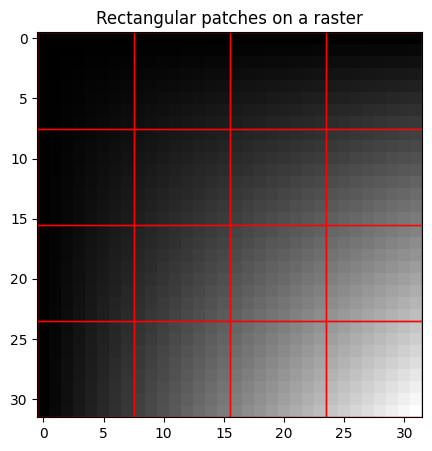

In [2]:
arr = np.outer(np.linspace(0, 1, 32), np.linspace(0, 1, 32)).astype(np.float32)
field = RasterField(
    GeoTensor(
        values=arr,
        transform=rasterio.Affine.identity(),
        crs="EPSG:32630",
    )
)

patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(8, 8)),
    sampler=SpatialRegularStride(step=8),
    window=SpatialBoxcar(),
    aggregation=SpatialByIndex(),
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(arr, cmap="gray")
for patch in patcher.split(field):
    r, c = patch.anchor
    ax.add_patch(
        plt.Rectangle(
            (c - 0.5, r - 0.5), 8, 8, fill=False, edgecolor="red", linewidth=1
        )
    )
ax.set_title("Rectangular patches on a raster")
plt.show()

## 2. `SpatialSphericalCap × GridDomain` — geodesic neighborhoods

Caps live on the sphere so they shrink near the poles in raster pixel terms.
Here we cap around the equator on a tiny lat/lon grid.

cap contains 145 grid cells


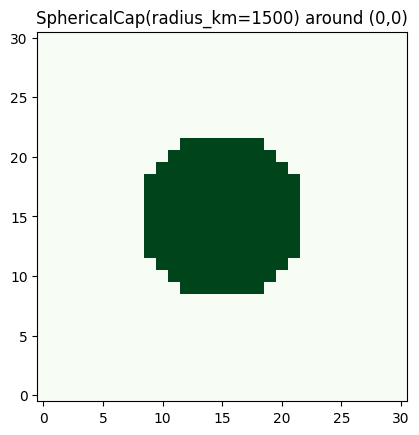

In [3]:
grid = GridDomain(
    coords={
        "lat": np.linspace(-30, 30, 31),
        "lon": np.linspace(-30, 30, 31),
    }
)
g = SpatialSphericalCap(radius_km=1500.0)
neighbours = g.neighborhood(grid, anchor=(0.0, 0.0))
print(f"cap contains {len(neighbours)} grid cells")

# Visualise the cap as a mask on the grid
mask = np.zeros((31, 31), dtype=bool)
mask[neighbours[:, 0], neighbours[:, 1]] = True
plt.imshow(mask, origin="lower", cmap="Greens")
plt.title("SphericalCap(radius_km=1500) around (0,0)")
plt.show()

## 3. `SpatialKNNGraph × PointDomain` — fixed-k neighbors

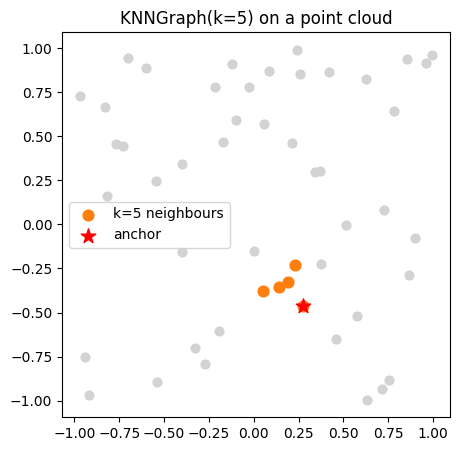

In [4]:
rng = np.random.default_rng(0)
pts = rng.uniform(-1, 1, size=(50, 2))
point_domain = PointDomain(coords=pts, kdtree=cKDTree(pts))

g_knn = SpatialKNNGraph(k=5)
anchor = pts[0]
neigh_idx = g_knn.neighborhood(point_domain, anchor=anchor)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pts[:, 0], pts[:, 1], c="lightgray", s=40)
ax.scatter(pts[neigh_idx, 0], pts[neigh_idx, 1], c="C1", s=60, label="k=5 neighbours")
ax.scatter([anchor[0]], [anchor[1]], c="red", s=120, marker="*", label="anchor")
ax.set_title("KNNGraph(k=5) on a point cloud")
ax.legend()
plt.show()

## 4. `SpatialRadiusGraph × PointDomain` — within-radius neighbors

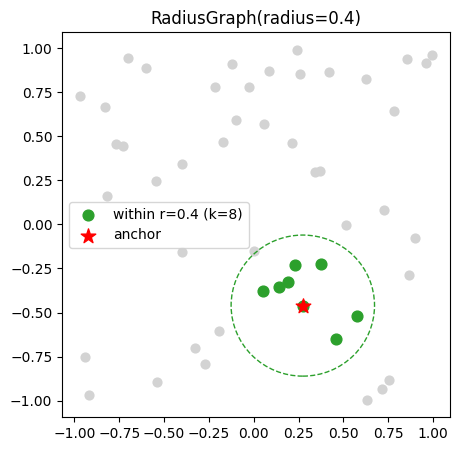

In [5]:
g_radius = SpatialRadiusGraph(radius=0.4)
neigh_idx_r = g_radius.neighborhood(point_domain, anchor=anchor)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pts[:, 0], pts[:, 1], c="lightgray", s=40)
ax.scatter(
    pts[neigh_idx_r, 0],
    pts[neigh_idx_r, 1],
    c="C2",
    s=60,
    label=f"within r=0.4 (k={len(neigh_idx_r)})",
)
ax.scatter([anchor[0]], [anchor[1]], c="red", s=120, marker="*", label="anchor")
circle = plt.Circle(anchor, 0.4, fill=False, edgecolor="C2", linestyle="--")
ax.add_patch(circle)
ax.set_title("RadiusGraph(radius=0.4)")
ax.legend()
plt.show()

## ByIndex aggregation

When patches don't form a dense grid (KNN, RadiusGraph, …) the natural
aggregation is `SpatialByIndex`, which returns a ``{anchor: result}`` dict
rather than trying to reconstruct a global field.

In [6]:
patcher = SpatialPatcher(
    geometry=SpatialKNNGraph(k=5),
    sampler=SpatialExplicit(anchors_=pts[:3]),
    window=SpatialBoxcar(),
    aggregation=SpatialByIndex(),
)
patches = list(
    patcher.split(
        _dummy_field := type(
            "F",
            (),
            {
                "domain": point_domain,
                "select": lambda self, idx: pts[idx],
                "with_data": lambda self, x: x,
            },
        )()
    )
)
print({tuple(p.anchor): len(p.data) for p in patches})

{(np.float64(0.2739233746429086), np.float64(-0.4604265724722594)): 5, (np.float64(-0.9180529521276106), np.float64(-0.9669447289429418)): 5, (np.float64(0.6265404784005448), np.float64(0.8255111545554434)): 5}
